In [21]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

In [22]:
RUN_ID = '1405_Jonatan'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e4)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,u_par,C_rate,SOC
0,17.046,2.787,0.460
1,21.084,4.542,0.370
2,28.287,3.852,0.544
3,5.953,3.160,0.691
4,12.364,2.216,0.578
...,...,...,...
9995,3.118,2.602,0.291
9996,27.880,2.880,0.849
9997,3.222,4.588,0.166
9998,25.080,2.665,0.696


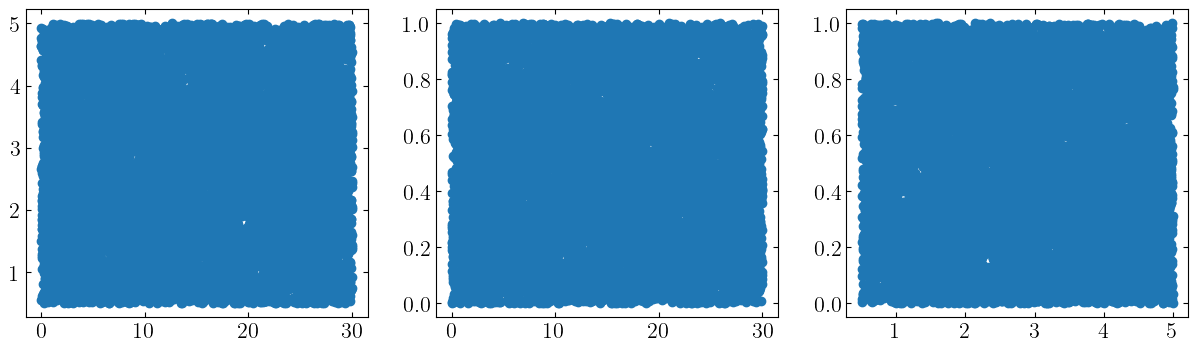

In [23]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('lhs_element.csv', usecols=['u_par', 'C_rate', 'SOC'])

f, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[2].plot(df['C_rate'],df['SOC'], 'o')

display(df)

In [24]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)

def sample_nn(c_rate, u_per, soc, s):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    sdot = sdot_nn(c_rate, u_per, soc, s)
    return R0.item(), R1.item(), C1.item(), k.item(), sdot.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),5+4))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        s = 0
        r0, r1,c1,k,sdot = sample_nn(c_rate, u_per, soc, s)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], sdot / ref_values['s'], c_rate, u_per, soc,s]
    return samples

samples = generate_data(df.values)


100%|██████████| 10000/10000 [00:10<00:00, 961.96it/s]


In [25]:
cols = VARIABLES + ['C', 'u_per', 'soc', 's_val']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples

data['u_per'] =  data['u_per'] / 30
data['C'] =  data['C'] / 5

data.describe() 

,R0,R1,C1,k,s,C,u_per,soc,s_val
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.0
mean,0.807749,4.251322,6.338343,2.802212,0.489320,0.550001,0.499999,0.50000,0.0
std,0.268592,6.906494,4.752930,0.342743,0.213736,0.259820,0.288690,0.28869,0.0
min,0.700000,0.474043,0.533203,2.274877,0.036171,0.100000,0.000033,0.00000,0.0
25%,0.700000,0.662648,1.773943,2.494504,0.318703,0.325000,0.250042,0.25000,0.0
50%,0.700000,0.834155,5.263081,2.761256,0.491126,0.550000,0.499983,0.50000,0.0
75%,0.700000,1.902795,10.752081,3.080579,0.661964,0.775000,0.749950,0.75000,0.0
max,1.500000,19.273393,16.400719,3.539700,0.917391,1.000000,0.999967,1.00000,0.0


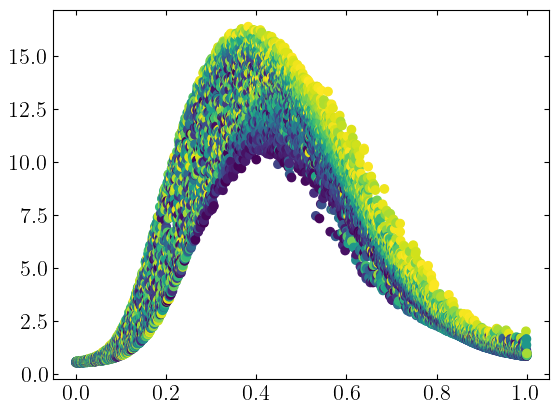

In [26]:
# plotting
arg_soc_sort = np.argsort(df_samples['soc'])
soc_sort = df_samples['soc'].values[arg_soc_sort]
R0_sort = df_samples['R0'].values[arg_soc_sort]
R1_sort = df_samples['R1'].values[arg_soc_sort]
C1_sort = df_samples['C1'].values[arg_soc_sort]
k_sort = df_samples['k'].values[arg_soc_sort]

#plt.plot(soc_sort, R0_sort, '-', label='R0')
#plt.plot(soc_sort, R1_sort, '-', label='R1')
plt.scatter(soc_sort, C1_sort, c = df_samples['u_per'].values[arg_soc_sort], label='C1')
#plt.plot(soc_sort, k_sort, '-', label='k')

# Importing data

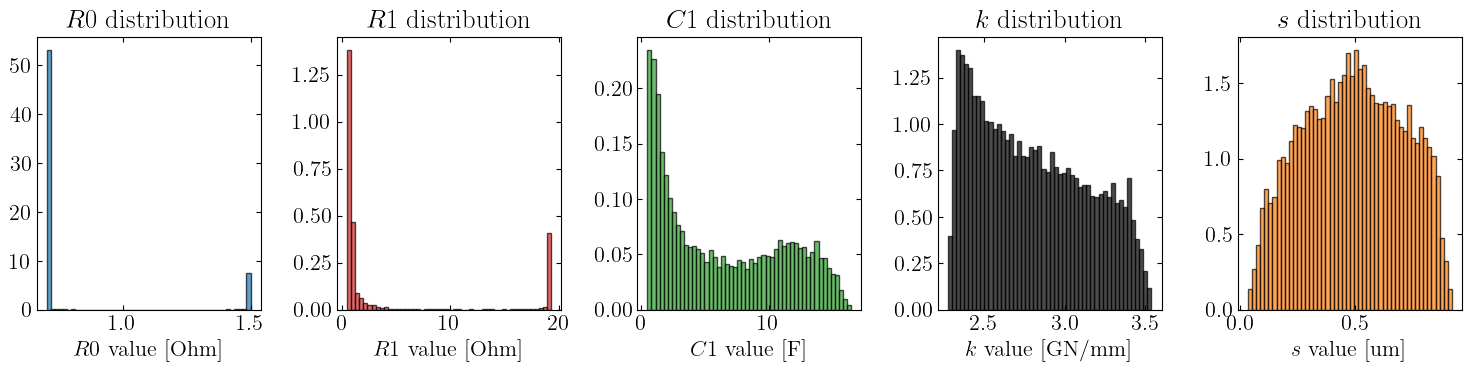

In [27]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

# f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

# for i, var in enumerate(VARIABLES):
#     ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
#     ax[i].set_title(f'${var}$ distribution')
#     ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
# plt.tight_layout()
# plt.show()

In [28]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values #/ REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values #/ REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values #/ REF_VALUES['C1']
    Y_k  = d_frame['k'].values  #/ REF_VALUES['k']
    try:
        Y_s = d_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [29]:
split_train = int(len(data) * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[:split_train]
    data_test   = data[split_train:]

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


No s column found, using reference value for all samples
Using every 1th data point for symbolic regression, total points: 8000
No s column found, using reference value for all samples
Using every 1th data point for symbolic regression, total points: 2000


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_1405_Jonatan...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.071200974
Equation: 0.8062239

Model 1: Complexity=3, Loss=0.047536775
Equation: 0.59296256 ^ soc

Model 2: Complexity=4, Loss=0.04138939
Equation: 1.4728807 - sqrt(soc)

Model 3: Complexity=5, Loss=0.023282088
Equation: (0.00031858392 ^ soc) + 0.68226147

Model 4: Complexity=7, Loss=0.02104042
Equation: ((C * 0.0009799164) ^ soc) - -0.6754131

Model 5: Complexity=8, Loss=0.014322072
Equation: exp(soc * (-4.4120107 / C)) + 0.68302256

Model 6: Complexity=9, Loss=0.005556881
Equation: exp(cube(soc * (-4.0255537 / C))) + 0.6862029

Model 7: Complexity=10, Loss=0.003919983
Equation: exp(cube(cube((soc * -4.048301) / C))) + 0.67984265

Model 8: Complexity=12, Loss=0.0009892196
Equation: (exp(cube(cube(soc * (-3.9685192 / C)))) - -0.6526676) ^ 0.83889824

Model 9: Complexity=13, Loss=0.00091969647
Equation: sqrt((exp(cube(cube(soc * (-4.0581784 / C)))) * 1.8361852) + 0.48883614)

Model 10: Complexity=14, Loss=0.000376516
Equation: (exp(cube(cube(((-7.0056796 / 

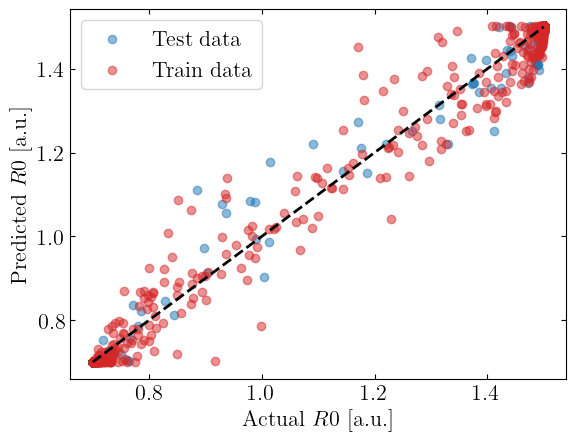

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (exp(soc**27*(-3.2632358*(C - 0.79116106)**2 - 5.118107/(C + soc + 0.030538386))**27) + 0.646354)**0.8162046
Loss: 0.00016286207
Best model complexity: 24


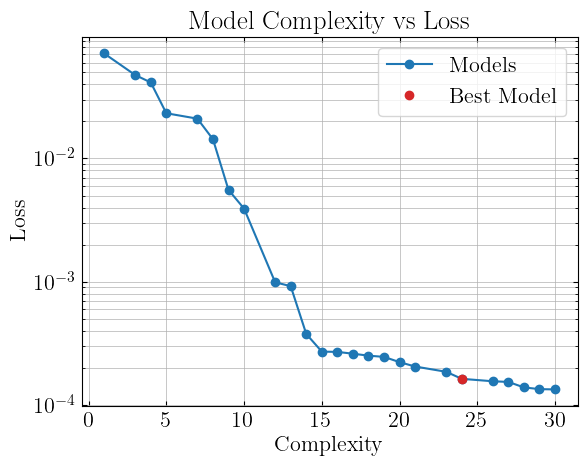

In [30]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_1405_Jonatan...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=47.26334
Equation: 4.227613

Model 1: Complexity=3, Loss=44.68271
Equation: 4.7285647 - soc

Model 2: Complexity=4, Loss=28.893105
Equation: cube(2.1657639 - soc)

Model 3: Complexity=5, Loss=13.722984
Equation: (1.5152007 - soc) ^ 7.5948305

Model 4: Complexity=6, Loss=11.211506
Equation: C / (square(soc) + 0.030329812)

Model 5: Complexity=7, Loss=8.178075
Equation: cube(exp(1.0742236 - (soc / C)))

Model 6: Complexity=8, Loss=6.9113307
Equation: cube(exp(2.100999 - exp(soc / C)))

Model 7: Complexity=9, Loss=2.625621
Equation: exp(cube((soc * -2.7495325) / C) + 3.0501795)

Model 8: Complexity=10, Loss=0.5348604
Equation: cube(exp(exp(((soc / C) ^ 12.551142) * -260513.17)))

Model 9: Complexity=11, Loss=0.45426252
Equation: exp(exp((((soc / C) ^ 14.313847) * -1.7019695e6) - -1.085726))

Model 10: Complexity=12, Loss=0.44619477
Equation: cube(exp(exp(((soc / C) ^ 13.742905) * -873762.1)) + -0.033895973)

Model 11: Complexity=13, Loss=0.4236068
Equation: exp

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(274.6644030817*exp(soc - 646076316.752898*soc**18/C**18) + 62.6917587746992*exp(-32.32981*soc**2/C)) + 0.7298293
Loss: 0.14853263
Best model complexity: 26


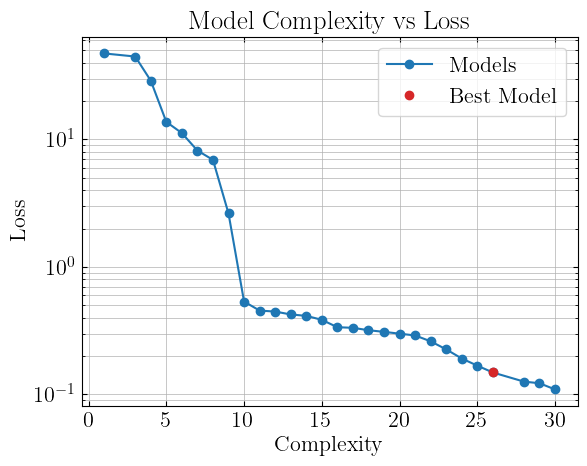

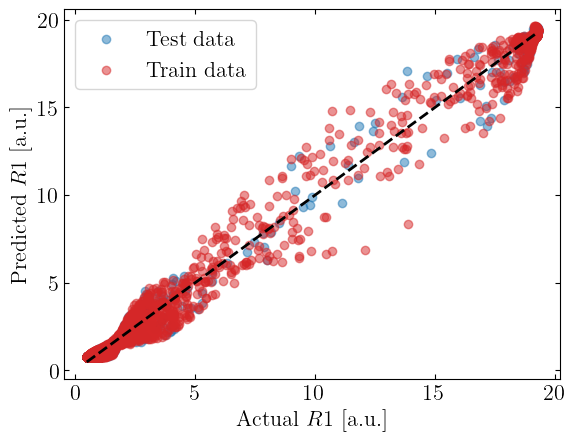

In [31]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_1405_Jonatan...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=22.426449
Equation: 6.336549

Model 1: Complexity=3, Loss=22.030058
Equation: 6.8369527 - soc

Model 2: Complexity=4, Loss=21.241776
Equation: 6.5867596 - cube(soc)

Model 3: Complexity=5, Loss=18.261642
Equation: cube(2.053243 - cube(soc))

Model 4: Complexity=6, Loss=7.6954083
Equation: (square(soc) - soc) * -40.54713

Model 5: Complexity=7, Loss=2.394411
Equation: soc / (cube(square(soc)) + 0.02709239)

Model 6: Complexity=8, Loss=1.5432694
Equation: square(soc / (square(square(soc)) + 0.08134286))

Model 7: Complexity=10, Loss=1.384483
Equation: square(soc / (square(square(soc)) + 0.084061675)) + d

Model 8: Complexity=11, Loss=1.3524104
Equation: cube(square((-1.2424198 + soc) / 0.34828547) * soc) + d

Model 9: Complexity=12, Loss=1.1196027
Equation: square(soc / ((square(square(soc)) + 0.07206326) + (C * 0.017304832)))

Model 10: Complexity=13, Loss=0.87849694
Equation: exp(cube((1.5065663 - cube(soc)) - exp(C - (soc / 0.11796115))))

Model 11: Complex

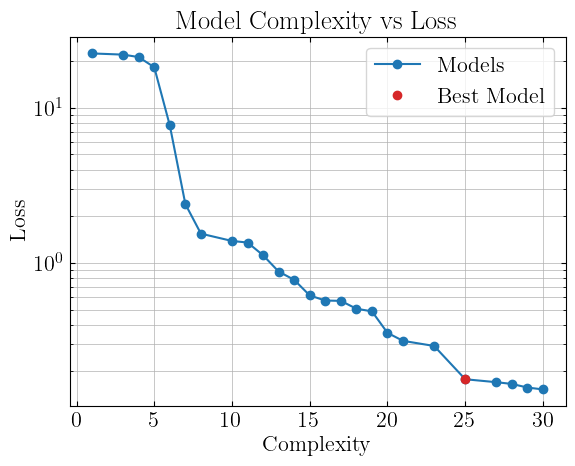

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (-exp(C*(-19.953726)) - exp(C - 7.164559*soc) + exp((d*0.073990166 - soc)**3 + 0.54134184))**6 + 0.9356649
Loss: 0.17761344
Best model complexity: 25


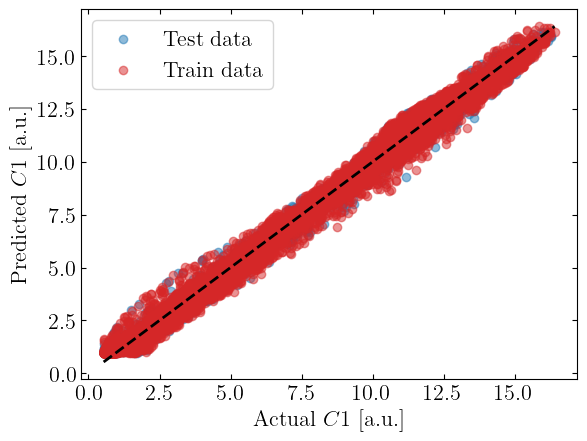

In [32]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_1405_Jonatan...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.11682984
Equation: 2.8031685

Model 1: Complexity=3, Loss=0.0053649605
Equation: d + 2.3021178

Model 2: Complexity=4, Loss=0.004927956
Equation: square(d) + 2.4693575

Model 3: Complexity=5, Loss=0.0013040259
Equation: -6.665759 / (d + -2.9137268)

Model 4: Complexity=7, Loss=0.001288965
Equation: (exp(d) + 1.6850536) ^ 0.8424481

Model 5: Complexity=9, Loss=4.3406122e-05
Equation: -6.6680202 / ((-2.8646936 - (soc * 0.10033453)) + d)

Model 6: Complexity=10, Loss=2.5656227e-05
Equation: (0.7079214 - (soc * 0.030461444)) * (exp(d) + 2.3271322)

Model 7: Complexity=12, Loss=1.2718669e-05
Equation: (0.9569731 ^ soc) * ((exp(d) + 1.7247703) ^ 0.8521781)

Model 8: Complexity=13, Loss=1.22952515e-05
Equation: ((exp(d) + 1.6532278) * ((soc * -0.053887766) + 1.0482221)) ^ 0.8345756

Model 9: Complexity=14, Loss=1.2294474e-05
Equation: (((exp(d) + 1.3891749) ^ 0.84665394) * (0.95281106 ^ soc)) + 0.2568977

Model 10: Complexity=15, Loss=8.545583e-06
Equation: (exp(

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -0.6442334*(0.118677706*sqrt(d) + 1.1115587)**soc + sqrt(exp(2.19244962*exp(0.268977470043643*d**1.104098)))
Loss: 3.4272423e-06
Best model complexity: 24


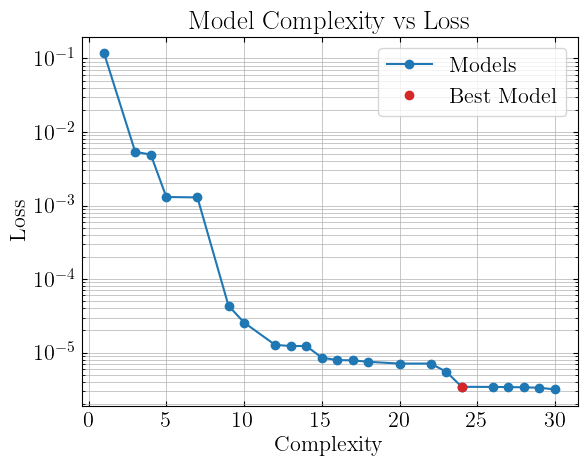

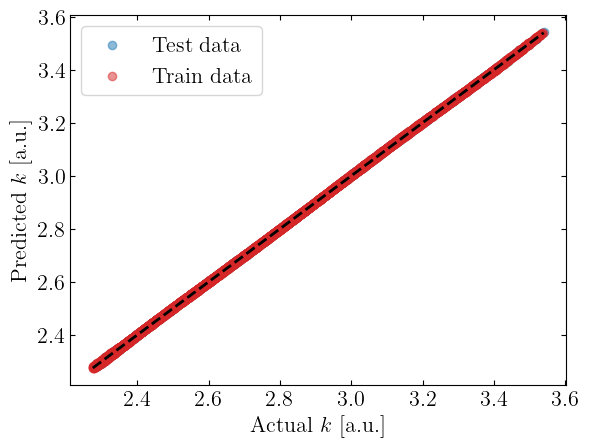

In [33]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

In [34]:
# import_reload()
# model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION, elem = 's')
# df_model_s = model_s.equations_
# Param_symbol.print_models(df_model_s)
# Param_symbol.print_best_model(model_s, s = True)
# Param_symbol.pareto_plot(model_s)
# Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [35]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    #'s':  model_s
}

In [36]:
# def plot_soc(models, df_samples):
#     C_fixed = df_samples['C'].iloc
#     u_per_fixed = traj['u_per']
#     soc = traj['soc'].values

#     f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

#     for var in VARIABLES:
#         model = models[var]
#         if var == 's':
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
#             Y_true = traj['sdot']
#         else:
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
#             Y_true = traj[var]
#         Y_plot = model.predict(X_plot) * REF_VALUES[var]
#         ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
#         ax[VARIABLES.index(var)].set_xlabel('SOC')
#         ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
#         ax[VARIABLES.index(var)].legend()
#         ax[VARIABLES.index(var)].invert_xaxis()
#     plt.tight_layout()



# traj = get_traj(trajectory_id = 1, test = True)
# plot_soc(MODEL_DICT, traj)

In [37]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [38]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    #Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    #Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')